In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [4]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("student_exam_performance (4).csv")

df.head(10)

,student_id,hours_studied,attendance_percentage,sleep_hours,exam_score
0,1,2.2,92,7.9,77
1,2,2.2,61,6.4,46
2,3,6.6,98,4.3,44
3,4,7.1,95,8.7,78
4,5,6.5,89,5.2,85
5,6,3.0,78,7.7,89
6,7,3.6,58,4.5,97
7,8,5.0,79,9.0,32
8,9,2.9,59,8.7,76
9,10,6.3,75,8.1,23


In [5]:
df.dtypes

student_id                 int64
hours_studied            float64
attendance_percentage      int64
sleep_hours              float64
exam_score                 int64
dtype: object

In [6]:
df.isna().sum()

student_id               0
hours_studied            0
attendance_percentage    0
sleep_hours              0
exam_score               0
dtype: int64

In [7]:
df_missing = df.copy()
df_missing.loc[0:5, 'exam_score'] = np.nan
df_missing.isna().sum()

student_id               0
hours_studied            0
attendance_percentage    0
sleep_hours              0
exam_score               6
dtype: int64

In [8]:
df_removed = df_missing.dropna()
df_removed.shape

(194, 5)

In [9]:
df_missing.shape

(200, 5)

In [12]:
df_imputed_mean = df_missing.copy()

df_imputed_mean['exam_score'] = df_imputed_mean['exam_score'].fillna(
    df_imputed_mean['exam_score'].mean()
)

df_imputed_mean.head(10)

,student_id,hours_studied,attendance_percentage,sleep_hours,exam_score
0,1,2.2,92,7.9,61.298969
1,2,2.2,61,6.4,61.298969
2,3,6.6,98,4.3,61.298969
3,4,7.1,95,8.7,61.298969
4,5,6.5,89,5.2,61.298969
5,6,3.0,78,7.7,61.298969
6,7,3.6,58,4.5,97.000000
7,8,5.0,79,9.0,32.000000
8,9,2.9,59,8.7,76.000000
9,10,6.3,75,8.1,23.000000


In [13]:
df_imputed_mean.shape

(200, 5)

In [14]:
df_missing.shape

(200, 5)

In [15]:
df_imputed_median = df_missing.copy()

df_imputed_median['exam_score'] = df_imputed_median['exam_score'].fillna(
    df_imputed_median['exam_score'].median()
)

df_imputed_median.head(10)

,student_id,hours_studied,attendance_percentage,sleep_hours,exam_score
0,1,2.2,92,7.9,61.5
1,2,2.2,61,6.4,61.5
2,3,6.6,98,4.3,61.5
3,4,7.1,95,8.7,61.5
4,5,6.5,89,5.2,61.5
5,6,3.0,78,7.7,61.5
6,7,3.6,58,4.5,97.0
7,8,5.0,79,9.0,32.0
8,9,2.9,59,8.7,76.0
9,10,6.3,75,8.1,23.0


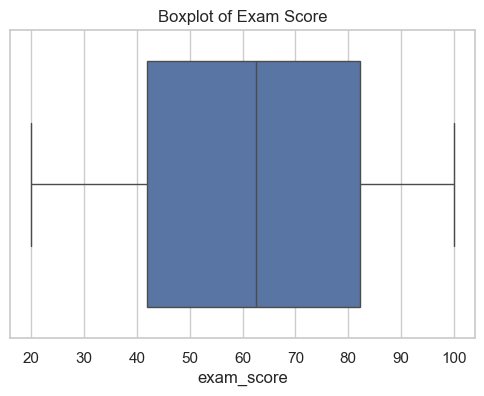

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['exam_score'])
plt.title("Boxplot of Exam Score")
plt.show()

In [17]:
Q1 = df['exam_score'].quantile(0.25)
Q3 = df['exam_score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['exam_score'] < lower) | (df['exam_score'] > upper)]

outliers.head()

,student_id,hours_studied,attendance_percentage,sleep_hours,exam_score


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = ['hours_studied','attendance_percentage','sleep_hours','exam_score']

df_scaled = df[numeric_cols].copy()

df_scaled[numeric_cols] = scaler.fit_transform(df_scaled)

df_scaled.head()

,hours_studied,attendance_percentage,sleep_hours,exam_score
0,0.216216,0.84,0.78,0.7125
1,0.216216,0.22,0.48,0.3250
2,0.810811,0.96,0.06,0.3000
3,0.878378,0.90,0.94,0.7250
4,0.797297,0.78,0.24,0.8125


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ['hours_studied','attendance_percentage','sleep_hours','exam_score']

df_standardized = df[numeric_cols].copy()

df_standardized[numeric_cols] = scaler.fit_transform(df_standardized)

df_standardized.head()

,hours_studied,attendance_percentage,sleep_hours,exam_score
0,-0.840891,1.193519,0.929397,0.657975
1,-0.840891,-0.969538,-0.097939,-0.662661
2,1.176514,1.612175,-1.536211,-0.747863
3,1.405765,1.402847,1.477310,0.700576
4,1.130664,0.984191,-0.919809,0.998784


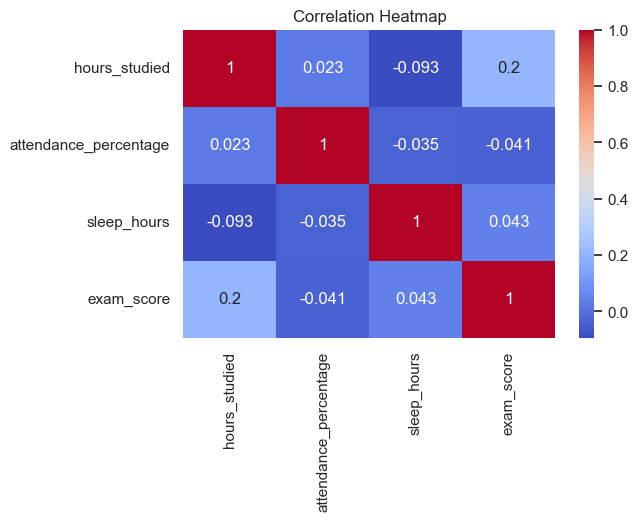

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(df[['hours_studied','attendance_percentage','sleep_hours','exam_score']].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [28]:
from sklearn.decomposition import PCA

X = df_standardized[['hours_studied','exam_score']]

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.60114641 0.39885359]
